In [1]:
import pandas as pd
import numpy as np
import glob
from tqdm import tqdm
import re
import json

def printShape(df, cols=[], msg=''):
    
    print(df.shape, end='  ')
    for col in cols:
        if col in df.columns:
            print(col, df[col].nunique(), end='  ')
    print(msg, flush=True)
    
    return df

PROJDATA = '../data'
PUBMED = f'{PROJDATA}/pubmed'
PLOS = f'{PROJDATA}/plos'
LARGE = f'{PROJDATA}/large_files'

# Load data

In [2]:
RAD = (
    pd.read_csv(
        f'{LARGE}/RAD.csv',dtype={'Publisher': str}, keep_default_na=False,
        usecols=['File','Publisher','Journal','AcptYear','RAD']
    )
    .pipe(printShape, cols=['File']) # 5354117
)

RAD.query('AcptYear == 2025').shape, RAD.query('AcptYear == 2024').shape # 437357, 621758

(5354117, 5)  File 5354117  


((437357, 5), (621758, 5))

In [3]:
classification = pd.read_csv(f'{LARGE}/ClassificationsAggregated.csv').pipe(printShape, cols=['File']) # 6865636

(6865636, 6)  File 6865636  


In [4]:
classification.head()

,File,BinoAbs,DetectAbsScore,DetectAbs,DetectAbs7,DetectIntro7
0,PMC012xxxxxx/PMC12000169.xml,False,0.000,False,False,False
1,PMC012xxxxxx/PMC12000882.xml,False,1.000,True,True,False
2,PMC012xxxxxx/PMC12001117.xml,False,0.758,True,True,False
3,PMC012xxxxxx/PMC12001119.xml,False,0.079,False,False,False
4,PMC012xxxxxx/PMC12001883.xml,False,0.082,False,False,False


In [5]:
paperYear = pd.read_csv(f'{LARGE}/PaperYear.csv', parse_dates=['Accepted']).pipe(printShape, cols=['File']) # 6060809

(6060809, 3)  File 6060809  


# Analysis and visualization

In [6]:
import pandas as pd
import numpy as np
import scipy
from scipy.stats import ttest_1samp, ttest_ind
import glob

from matplotlib import pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns
import matplotlib

cm = 1/2.54  # centimeters in inches
font = {'size': 7}
matplotlib.rc('font', **font)

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
plt.rcParams['pdf.use14corefonts'] = True

matplotlib.rcParams['grid.linewidth'] = 0.5
matplotlib.rcParams['axes.linewidth'] = 0.5

def set_size(w,h, ax=None):
    """ w, h: width, height in inches """
    if not ax: ax=plt.gca()
    l = ax.figure.subplotpars.left
    r = ax.figure.subplotpars.right
    t = ax.figure.subplotpars.top
    b = ax.figure.subplotpars.bottom
    figw = float(w)/(r-l)
    figh = float(h)/(t-b)
    ax.figure.set_size_inches(figw, figh)

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def groupPlot(
    df, freq, ax, datetime='Accepted', outcome='RAD', hue=None,
    colors=['#69bade', '#f34d4d'], ls=['-','-'], lw=1,
    legend=False
):
    
    assert(freq in ['MS','QS','W', 'M', 'Q', 'YS', 'ME', 'QE']) # Added standard aliases just in case
    
    df[outcome] = pd.to_numeric(df[outcome])

    # 1. Determine grouping columns
    # If hue is provided, group by [time, hue]. If not, just group by time.
    group_cols = [pd.Grouper(key=datetime, freq=freq)]
    if hue is not None:
        group_cols.append(hue)

    # 2. Calculate Mean and CI
    stats = df.groupby(group_cols)[outcome].agg(['mean', 'std', 'count'])

    # Calculate the 95% Confidence Interval bounds
    stats['ci_hi'] = stats['mean'] + 1.96 * (stats['std'] / np.sqrt(stats['count']))
    stats['ci_lo'] = stats['mean'] - 1.96 * (stats['std'] / np.sqrt(stats['count']))

    # 3. Plotting Logic
    if hue is not None:
        # Multi-line logic
        categories = stats.index.get_level_values(hue).unique()
        for ind, cat in enumerate(categories):
            data_cat = stats.xs(cat, level=hue)
            line, = ax.plot(data_cat.index, data_cat['mean'], label=cat, linewidth=lw, color=colors[ind], ls=ls[ind])
            ax.fill_between(data_cat.index, data_cat['ci_lo'], data_cat['ci_hi'], 
                            color=line.get_color(), alpha=0.2)
    else:
        # Single-line logic
        line, = ax.plot(stats.index, stats['mean'], linewidth=lw, color=colors[0], ls=ls[0])
        ax.fill_between(stats.index, stats['ci_lo'], stats['ci_hi'], 
                        color=line.get_color(), alpha=0.2)

    # 4. Tick Configuration
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    
    if freq in ['MS', 'M']:
        ax.xaxis.set_minor_locator(mdates.MonthLocator())
    elif freq in ['QS', 'Q']:
        ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
    elif freq=='W':
        ax.xaxis.set_minor_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
    elif freq == 'YS':
        ax.xaxis.set_major_locator(mdates.YearLocator(base=5))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.xaxis.set_minor_locator(mdates.YearLocator())
        
    ax.xaxis.set_minor_formatter(plt.NullFormatter())

    # Aesthetics
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel(outcome)
    
    if hue is not None and legend is True:
        ax.legend(title=hue, frameon=True)
        
    return stats

In [8]:
import numpy as np
from scipy.interpolate import make_smoothing_spline
import scipy

def CI(data, confidence=0.95):
    
    a = 1.0 * np.array(data)
    n = len(a)
    
    if n < 2: return 0
    
    se = scipy.stats.sem(a)
    h = se * scipy.stats.t.ppf((1 + confidence) / 2., n-1)
    
    return h

def plotFigure(
    df, x='percentile', y='LogFunding', ax=None, spline=False,
    markerSize=2, barColor='#377eb8', lineColor='#4daf4a'
):

    if ax is None:
        ax = plt.gca()
        
    df = df.dropna(subset=[x, y])

    toPlot = (
        df.groupby(x, observed=True)[y].mean().reset_index()
        
        .merge(
            df.groupby(x, observed=True)[y].apply(CI).reset_index().rename(columns={y: 'err'}), on=x
        )
    )

    ax.errorbar(
        y=toPlot[y], x=toPlot.index, yerr=toPlot['err'], color=barColor,
        fmt='o', markersize=markerSize, linewidth=0.5, capsize=1, capthick=0.5
    )

    if spline:
        spl = make_smoothing_spline(toPlot[x], toPlot[y], lam=None)
        ax.plot(toPlot[x], spl(toPlot[x]), '--', color=lineColor, alpha=0.5)
    else:
        sns.regplot(data=df, x=x, y=y, ax=ax, scatter=False, line_kws={"lw": 1, 'ls': '--'}, color=lineColor)

    return ax

In [9]:
from scipy.stats import spearmanr

In [10]:
%%time
RAD2plot = (
    paperYear
    .merge(RAD.drop('AcptYear', axis=1), on='File')
    .query('AcptYear<=2025')
    .merge(classification, on=['File'])
    .pipe(printShape, cols=['File']) # 5354115
)
# (5354115, 22)  File 5354115 

(5354115, 11)  File 5354115  
CPU times: user 19.6 s, sys: 460 ms, total: 20.1 s
Wall time: 20.2 s


## Binary classification of LLM-assistance

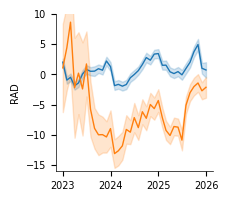

In [11]:
fig, ax = plt.subplots()

set_size(4*cm, 4*cm, ax)

subset2plot = RAD2plot[(RAD2plot.Accepted >= '2022-12-01') & (RAD2plot.Accepted <= '2025-12-31')].copy()
stats = groupPlot(subset2plot, 'ME', hue='DetectAbs7', ax=ax, legend=False, colors=['tab:blue','tab:orange'])

ax.set_ylim(-16, 10)

plt.savefig('../figures/LLM-RAD.pdf',bbox_inches = 'tight', pad_inches = 0)

### Robustness checks using alternative classifiers

(-13.0, 10.0)

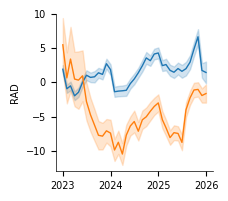

In [12]:
fig, ax = plt.subplots()

set_size(4*cm, 4*cm, ax)

subset2plot = RAD2plot[(RAD2plot.Accepted >= '2022-12-01') & (RAD2plot.Accepted <= '2025-12-31')].copy()
groupPlot(subset2plot, 'ME', hue='DetectAbs', ax=ax, legend=False, colors=['tab:blue','tab:orange'])

ax.set_ylim(-13, 10)

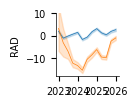

In [13]:
fig, ax = plt.subplots()

set_size(1.6*cm, 1.6*cm, ax)

subset2plot = RAD2plot[(RAD2plot.Accepted >= '2022-12-01') & (RAD2plot.Accepted <= '2025-12-31')].copy()
groupPlot(subset2plot, 'QE', hue='DetectIntro7', ax=ax, legend=False, colors=['tab:blue','tab:orange'], lw=0.5)

ax.set_ylim(-18, 10)
plt.savefig('../figures/LLM-RAD_inset_1.pdf',bbox_inches = 'tight', pad_inches = 0)

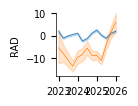

In [14]:
fig, ax = plt.subplots()

set_size(1.6*cm, 1.6*cm, ax)

subset2plot = RAD2plot[(RAD2plot.Accepted >= '2022-12-01') & (RAD2plot.Accepted <= '2025-12-31')].copy()
groupPlot(subset2plot, 'QE', hue='BinoAbs', ax=ax, legend=False, colors=['tab:blue','tab:orange'],lw=0.5)

ax.set_ylim(-18, 10)
plt.savefig('../figures/LLM-RAD_inset_2.pdf',bbox_inches = 'tight', pad_inches = 0)

## Continuous classification of AI-assistance

In [15]:
BINS=20

continuous2Plot = (
    RAD2plot[['File','Accepted','AcptYear','RAD','DetectAbsScore']]
    
    .query('DetectAbsScore >0')
    .assign(
        DetectAbsBins=lambda df: pd.qcut(
            df['DetectAbsScore'], q=BINS, duplicates='drop', labels=[x for x in range(BINS-1)]
        )
    )
    .assign(
        DetectAbsBinLabels=lambda df: pd.qcut(
            df['DetectAbsScore'], q=BINS, duplicates='drop',
        )
    )
)

In [16]:
continuous2Plot[['DetectAbsBins', 'DetectAbsBinLabels']].drop_duplicates().sort_values(by='DetectAbsBins').head(2)
# (0.0, 0.051]
# (0.051, 0.089]

,DetectAbsBins,DetectAbsBinLabels
6,0,"(0.0, 0.051]"
9,1,"(0.051, 0.089]"


In [17]:
continuous2Plot[['DetectAbsBins', 'DetectAbsBinLabels']].drop_duplicates().sort_values(by='DetectAbsBins').tail(3)
# (0.5, 0.542]
# (0.542, 0.688]
# (0.688, 1.0]

,DetectAbsBins,DetectAbsBinLabels
379,16,"(0.5, 0.542]"
0,17,"(0.542, 0.688]"
23,18,"(0.688, 1.0]"


In [18]:
spearmanr(continuous2Plot.query('AcptYear<=2022').DetectAbsScore, continuous2Plot.query('AcptYear<=2022').RAD) # -0.008

SignificanceResult(statistic=-0.00836292526763728, pvalue=5.795800092478691e-33)

In [19]:
spearmanr(continuous2Plot.query('AcptYear>2022').DetectAbsScore, continuous2Plot.query('AcptYear>2022').RAD) # -0.034

SignificanceResult(statistic=-0.0341302236343653, pvalue=7.767314266383434e-306)

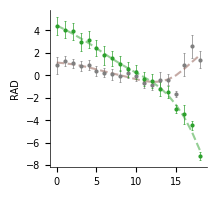

In [20]:
fig, ax = plt.subplots()
# https://colorbrewer2.org/#type=diverging&scheme=PiYG&n=4

set_size(4*cm, 4*cm, ax)

plotFigure(
    continuous2Plot.query('AcptYear<=2022'), x='DetectAbsBins', y='RAD', ax=ax, spline=True,
    barColor='tab:gray', lineColor='tab:brown'
)

plotFigure(
    continuous2Plot.query('AcptYear>2022'), x='DetectAbsBins', y='RAD',
    barColor='tab:green', lineColor='tab:green', ax=ax, spline=True
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_ylabel('RAD')

plt.savefig('../figures/Continuous-RAD.pdf',bbox_inches = 'tight', pad_inches = 0)

## DiD

In [21]:
from statsmodels.formula.api import ols, logit
from scipy.stats import ttest_ind
from statsmodels.iolib.summary2 import summary_col

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def getParamsToPlot(res, classifier='DetectAbs'):
    params = res.params
    bse = res.bse
    pvals = res.pvalues
    
    # Regex to match interaction terms like:
    # 'DetectIntro7[T.True]:C(EventBin, Treatment(reference=0))[T.-6]'
    pattern = re.compile(
        rf'{classifier}\[T\.True\]:C\(EventBin, Treatment\(reference=0\)\)\[T\.(?P<bin>-?\d+)\]'
    )
    
    rows = []
    
    for name in params.index:
        m = pattern.match(name)
        if m:
            event_bin = int(m.group("bin"))
            coef = params[name]
            se = bse[name]
            p = pvals[name]
    
            # significance stars
            stars = ""
            if p < 0.001:
                stars = "***"
            elif p < 0.01:
                stars = "**"
    
            rows.append({
                "EventBin": event_bin,
                "coef": coef,
                "se": se,
                "pval": p,
                "stars": stars
            })
    
    coef_df = pd.DataFrame(rows).sort_values("EventBin")
    
    # 95% confidence intervals
    coef_df["lower"] = coef_df["coef"] - 1.96 * coef_df["se"]
    coef_df["upper"] = coef_df["coef"] + 1.96 * coef_df["se"]
    
    base_year = 2022
    coef_df["Year"] = base_year + coef_df["EventBin"]

    return coef_df

In [22]:
def plotCoeff(coef_df, base_year = 2022, ax=None):

    if ax is None:
        fig, ax = plt.subplots()
    # https://colorbrewer2.org/#type=diverging&scheme=PiYG&n=4
    
    plt.errorbar(
        coef_df["Year"],
        coef_df["coef"],
        yerr=1.96 * coef_df["se"],
        marker="o",
        color='tab:orange',
        linestyle='none',
        markersize=2,
        elinewidth=0.5,
        capsize=1
    )
    
    for _, row in coef_df.iterrows():
        if not np.isnan(row["pval"]):
            
            if row['stars'] == '':
                label = f"p={row['pval']:.3g}"
            else:
                label = f"{row['stars']}"
                
            
            plt.text(
                row["Year"],
                row["coef"] + 2*row["se"] + 0.5,  # vertical offset
                label,
                va="bottom",
                rotation=90
            )
    
    plt.axhline(0, linestyle='--', color='grey', lw=0.5)   # zero effect line
    plt.axvline(base_year, linestyle='--', color='grey', lw=0.5)    # baseline year (EventBin = 0, i.e. 2022)
    
    # plt.xlabel("Event time (EventBin, years relative to 2022)")
    plt.ylabel("OLS-estimated coefficients (vs 2022)")
    plt.tight_layout()
    ax = plt.gca()
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    ax.set_xticks([2016, 2018, 2020, 2022, 2024])

    return ax

In [23]:
%%time
RAD2regress = (
    paperYear.merge(RAD.drop('AcptYear', axis=1), on='File')
    
    .query('AcptYear<=2025')
    .query('AcptYear>=2016')
    .pipe(printShape, msg='2016 to 2025')
    
    .merge(classification[['File','DetectAbs','DetectAbs7']], on=['File'])
    .pipe(printShape, cols=['File'], msg='get classification')
    
    .assign(quarter=lambda df: df['Accepted'].dt.to_period('Q').astype(str))
    
    .assign(AfterGPT=lambda df: df.AcptYear >= 2023)
    .assign(EventBin=lambda df: df.AcptYear - 2022)
    
    .assign(AcptMonth=lambda df: df.Accepted.apply(lambda x: x.month))
)
# (4473494, 7)  2016 to 2025
# (4473494, 8)  File 4473494  get classification

(4473494, 6)  2016 to 2025
(4473494, 8)  File 4473494  get classification
CPU times: user 27.1 s, sys: 860 ms, total: 28 s
Wall time: 28.3 s


In [24]:
%%time
m = 'RAD ~ C(EventBin, Treatment(reference=0)) + DetectAbs7 + DetectAbs7 * C(EventBin, Treatment(reference=0)) + C(AcptMonth)'
res = ols(m, data=RAD2regress).fit()

CPU times: user 1min 7s, sys: 1.19 s, total: 1min 8s
Wall time: 1min 8s


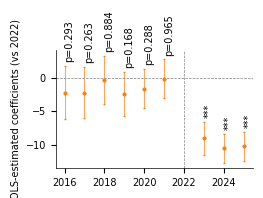

In [25]:
ax = plt.gca()

coeff = getParamsToPlot(res, 'DetectAbs7')
ax = plotCoeff(coeff, ax=ax)
set_size(5*cm, 3*cm, ax)

plt.savefig('../figures/RAD-DiD.pdf',bbox_inches = 'tight', pad_inches = 0)